In [1]:
import matplotlib.pyplot as plt

In [2]:
Initial_Canopy_Storage            = 1
Canopy_Storage                    = 1
InitialSurface_Storage            = 1
Surface_Storage_Capacity          = 1
Initial_Soil_Storage              = 1
Initial_Gw1_Storage               = 1
Initial_Gw2_Storage               = 1
Soil_Maximum_Infiltration         = 1
Soil_Storage_Capacity             = 1
Soil_Tension_Capacity             = 0.1
Soil_Maximum_Percolation          = 1
Groundwater_1_Storage             = 1
Groundwater_1_Routing             = 1
Groundwater_1_Maximum_Percolation = 1
Groundwater_2_Storage             = 1
Groundwater_2_Routing             = 1
Groundwater_2_Maximum_Percolation = 1
Storage_Coefficient               = 1
GW_1_Routing_Coefficient          = 1
GW_2_Routing_Coefficient          = 1

In [3]:
params_values = [Initial_Canopy_Storage, Canopy_Storage, 
                    InitialSurface_Storage, Surface_Storage_Capacity, 
                    Initial_Soil_Storage, Initial_Gw1_Storage, Initial_Gw2_Storage, 
                    Soil_Maximum_Infiltration, Soil_Storage_Capacity, Soil_Tension_Capacity,
                    Soil_Maximum_Percolation, Groundwater_1_Storage, Groundwater_1_Routing,
                    Groundwater_1_Maximum_Percolation, Groundwater_2_Storage, Groundwater_2_Routing,
                    Groundwater_2_Maximum_Percolation, Storage_Coefficient,
                    GW_1_Routing_Coefficient, GW_2_Routing_Coefficient]

In [50]:
class hms_model(object):
    import os
    import datetime
    def __init__(self, Path_model,name_model, Name_run, name_basin, name_control,
                 Time_interval_c,
                 pathname,name_precip, startDate, endDate, Path_o, qobs, version_hms,stCal,enCal):
        
        self.Path_model      = Path_model
        self.name_model      = name_model
        self.Name_run        = Name_run
        self.name_basin      = name_basin
        self.name_control    = name_control
        self.Time_interval_c = Time_interval_c
        self.pathname        = pathname
        self.name_precip     = name_precip
        self.startDate       = startDate
        self.endDate         = endDate
        self.Path_o          = Path_o
        self.qobs            = qobs
        self.version_hms     = version_hms
        self.stCal           = stCal
        self.enCal           = enCal
        
        return
    
    def get_obs(self):
        qobs=self.qobs.loc[self.stCal:self.enCal].values
        return qobs
    
    def parameters_SMA (self, Initial_Canopy_Storage, Canopy_Storage, 
                    InitialSurface_Storage, Surface_Storage_Capacity, 
                    Initial_Soil_Storage, Initial_Gw1_Storage, Initial_Gw2_Storage, 
                    Soil_Maximum_Infiltration, Soil_Storage_Capacity, Soil_Tension_Capacity,
                    Soil_Maximum_Percolation, Groundwater_1_Storage, Groundwater_1_Routing,
                    Groundwater_1_Maximum_Percolation, Groundwater_2_Storage, Groundwater_2_Routing,
                    Groundwater_2_Maximum_Percolation, Storage_Coefficient,
                    GW_1_Routing_Coefficient, GW_2_Routing_Coefficient):
    
        parameters =[
        'Initial Canopy Storage Percent',
        'Canopy Storage Capacity',
        'Initial Surface Storage Percent',
        'Surface Storage Capacity',
        'Initial Soil Storage Percent',
        'Initial Gw1 Storage Percent',
        'Initial Gw2 Storage Percent',
        'Soil Maximum Infiltration',
        'Soil Storage Capacity',
        'Soil Tension Capacity',
        'Soil Maximum Percolation',
        'Groundwater 1 Storage Capacity',
        'Groundwater 1 Routing Coefficient',
        'Groundwater 1 Maximum Percolation',
        'Groundwater 2 Storage Capacity',
        'Groundwater 2 Routing Coefficient',
        'Groundwater 2 Maximum Percolation',
        'Storage Coefficient',
        'GW-1 Routing Coefficient',
        'GW-2 Routing Coefficient']


        params_values = [Initial_Canopy_Storage, Canopy_Storage, 
                        InitialSurface_Storage, Surface_Storage_Capacity, 
                        Initial_Soil_Storage, Initial_Gw1_Storage, Initial_Gw2_Storage, 
                        Soil_Maximum_Infiltration, Soil_Storage_Capacity, Soil_Tension_Capacity,
                        Soil_Maximum_Percolation, Groundwater_1_Storage, Groundwater_1_Routing,
                        Groundwater_1_Maximum_Percolation, Groundwater_2_Storage, Groundwater_2_Routing,
                        Groundwater_2_Maximum_Percolation, Storage_Coefficient,
                        GW_1_Routing_Coefficient, GW_2_Routing_Coefficient]

        fileObject = open(self.Path_model+self.name_basin+'_CAL.basin', "r")
        data = fileObject.read()
        data_new = data.split('\n')
        fileObject.close()

        for i, ii in enumerate(parameters):
            for j, jj  in enumerate(data.split('\n')):
                if ii in jj:
                    data_new[j] = '     '+ii+': '+str(float(jj.split(':')[1])*params_values[i])

        with open(self.Path_model+self.name_basin+'.basin', "w") as fh:
            for line in data_new:
                fh.write(line+'\n')
                
    def generate_run(self, exists_run =False):
    
        """ Esta función sobreescribe el fichero .run del modelo hidrológico HEC-HMS, incluyendo los escenarios que se quieren correr en el programa, y respetando los datos que contenga el 
            modelo inicial, es decir, que no borra los datos de las corridas anteriores, solamente incluye los datos de nuevas simulaciones que se quieran introducir en el programa.

        Input:
        ------
        Path_model:        Str. Se introduce la ruta en donde está el fichero .run a modificar dentro del modelo HEC-HMS.
        name_model:        Str. Se introduce el nombre del modelo HEC HMS.
        Name_Run:          Str. Nombre que se le quiere colocar a la nueva corrida.
        name_control:      Str. Se coloca el nombre del control.
        name_met:          Str. Nombre del módulo meteorológico
        name_control:      Str. Se coloca el nombre del control nuevo que se quiere crear.
        name_basin:        Str. Se introduce la ruta del modulo basin de la cuenca, para ello se debe abrir el modelo y verificar el nombre del Basin.

        Output:
        -------
        fichero_hms:      Str. Regresera el fichero sobre escrito .run del programa HEC HMS, incluyendo los nuevos datos de las simulaciones que se quieran hacer"""

        if exists_run==False:
            #Crea un fichero en blanco con extención .log necesario para realizar la corrida
            lines_new  = list()
            with open(self.Path_model+self.name_model+'.run', "w") as fh:
                for line in (lines_new):
                    fh.write(line)

            # Genera las lineas de código necesarias para ser almacenadas en el fichero .run
            lines_new_1  = list()
            lines_new_1.append('Run: '+self.Name_run.replace("_", " ")+'\n')  
            lines_new_1.append('     Default Description: Yes'+'\n')
            lines_new_1.append('     Log File: '+self.Name_run+'.log'+'\n')
            lines_new_1.append('     DSS File: '+self.Name_run+'.dss'+'\n')
            lines_new_1.append('     Is Save Spatial Results: No'+'\n')  
            lines_new_1.append('     Last Modified Date: 17 November 2020'+'\n')                             
            lines_new_1.append('     Last Modified Time: 09:31:48'+'\n')
            lines_new_1.append('     Basin: '+self.name_basin+'\n')
            lines_new_1.append('     Precip: '+self.name_precip.replace("_", " ")+'\n')       
            lines_new_1.append('     Control: '+self.name_control.replace("_", " ")+'\n')        
            lines_new_1.append('     Save State Type: None'+'\n') 
            lines_new_1.append('     Time-Series Output: Save All'+'\n')
            lines_new_1.append('End:'+'\n')
            lines_new_1.append('\n')    
        else:
            # Genera las lineas de código necesarias para ser almacenadas en el fichero .run
            lines_new_1  = list()
            lines_new_1.append('Run: '+self.Name_run.replace("_", " ")+'\n')  
            lines_new_1.append('     Default Description: Yes'+'\n')
            lines_new_1.append('     Log File: '+self.Name_run+'.log'+'\n')
            lines_new_1.append('     DSS File: '+self.Name_run+'.dss'+'\n')
            lines_new_1.append('     Is Save Spatial Results: No'+'\n')  
            lines_new_1.append('     Last Modified Date: 17 November 2020'+'\n')                             
            lines_new_1.append('     Last Modified Time: 09:31:48'+'\n')
            lines_new_1.append('     Basin: '+self.name_basin+'\n')
            lines_new_1.append('     Precip: '+self.name_met.replace("_", " ")+'\n')       
            lines_new_1.append('     Control: '+self.name_control.replace("_", " ")+'\n')        
            #lines_new_1.append('     Save State Type: None'+'\n') 
            lines_new_1.append('     Time-Series Output: Save All'+'\n')
            lines_new_1.append('End:'+'\n')
            lines_new_1.append('\n')      

        # Crea un fichero en blanco con extención .log necesario para realizar la corrida
        lines_new_2  = list()
        with open(self.Path_model+self.Name_run+'.log', "w") as fh:
             for line in (lines_new_2):
                    fh.write(line)

        #  Crea un fichero en blanco con extención necesario para realizar la corrida 
        fid2 = HecDss.Open(self.Path_model+self.Name_run+'.dss',version=6)
        fid2.close()


        ### sobreescribe el fichero con extensión .run donde se encuentra la carpeta del modelo HEC-HMS, rellenando los datos de corrida del modelo.
        with open(self.Path_model+self.name_model+'.run', "r+") as out_file:
                lines = out_file.readlines()
                out_file.close()

        with open(self.Path_model+self.name_model+'.run', "w") as fh:
            #for line in (lines[0:k]+lines_new_1+lines[k:]):
            for line in (lines+lines_new_1):
                fh.write(line)      

        #return print('################### El fichero .run fue creado satisfactoriamente ###############################') 
                
#     def generate_run(self):
    
#         """ Esta función sobreescribe el fichero .run del modelo hidrológico HEC-HMS, incluyendo los escenarios que se quieren correr en el programa, y respetando los datos que contenga el 
#             modelo inicial, es decir, que no borra los datos de las corridas anteriores, solamente incluye los datos de nuevas simulaciones que se quieran introducir en el programa.

#         Input:
#         ------
#         Path_model:        Str. Se introduce la ruta en donde está el fichero .run a modificar dentro del modelo HEC-HMS.
#         name_model:        Str. Se introduce el nombre del modelo HEC HMS.
#         Name_Run:          Str. Nombre que se le quiere colocar a la nueva corrida.
#         name_control:      Str. Se coloca el nombre del control.
#         name_control:      Str. Se coloca el nombre del control nuevo que se quiere crear.
#         name_basin:        Str. Se introduce la ruta del modulo basin de la cuenca, para ello se debe abrir el modelo y verificar el nombre del Basin.

#         Output:
#         -------
#         fichero_hms:      Str. Regresera el fichero sobre escrito .run del programa HEC HMS, incluyendo los nuevos datos de las simulaciones que se quieran hacer"""

#         # Crea un fichero en blanco con extención .log necesario para realizar la corrida
#         lines_new  = list()
#         with open(self.Path_model+self.name_model+'.run', "w") as fh:
#             for line in (lines_new):
#                 fh.write(line)

#         # Crea un fichero en blanco con extención .log necesario para realizar la corrida
#         lines_new_2  = list()
#         with open(self.Path_model+self.Name_run+'.log', "w") as fh:
#             for line in (lines_new_2):
#                 fh.write(line)

#         #  Crea un fichero en blanco con extención necesario para realizar la corrida 
#         lines_new_3  = list()
#         with open(self.Path_model+self.Name_run+'.dss', "w") as fh:
#             for line in (lines_new_3):
#                 fh.write(line)

#         # Genera las lineas de código necesarias para ser almacenadas en el fichero .run
#         lines_new_1  = list()
#         lines_new_1.append('Run: '+self.Name_run+'\n')  
#         lines_new_1.append('     Default Description: Yes'+'\n')
#         lines_new_1.append('     Log File: '+self.Name_run+'.log'+'\n')
#         lines_new_1.append('     DSS File: '+self.Name_run+'.dss'+'\n')                                 
#         lines_new_1.append('     Last Modified Date: 17 November 2020'+'\n')                             
#         lines_new_1.append('     Last Modified Time: 09:31:48'+'\n')
#         lines_new_1.append('     Basin: '+self.name_basin+'\n')
#         lines_new_1.append('     Precip: '+self.name_precip+'\n')       
#         lines_new_1.append('     Control: '+self.name_control+'\n')        
#         lines_new_1.append('     Save State Type: None'+'\n')        
#         lines_new_1.append('End:'+'\n')
#         lines_new_1.append('\n')      

#         ### sobreescribe el fichero con extensión .run donde se encuentra la carpeta del modelo HEC-HMS, rellenando los datos de corrida del modelo.
#         with open(self.Path_model+self.name_model+'.run', "r+") as out_file:
#                 lines = out_file.readlines()
#                 out_file.close()

#         with open(self.Path_model+self.name_model+'.run', "w") as fh:
#             #for line in (lines[0:k]+lines_new_1+lines[k:]):
#             for line in (lines_new_1):
#                 fh.write(line)      

#         return print('################### El fichero .run fue creado satisfactoriamente ###############################')

    def generate_control(self):  

        """ Esta función crea el fichero .control que contiene datos relevantes para la simulación y a su vez modifica el fichero .hms requerido para que el programa lea bien el fichero .control. 
            Los datos de entrada y salida corresponden a:

        Input:
        ------
        name_model:        Str. Se introduce el nombre del modelo HEC HMS.
        Path_model:        Str. Se introduce la ruta en donde está el fichero .hms a modificar dentro del modelo HEC-HMS.
        name_control:      Str. Se introduce el nombre que se le quiere poner al nuevo control.
        Start_Time_c:      Str. Se incluye la fecha de inicio del control, que debe coincidir con la fecha de inicio de la lluvia.
        End_Time_c:        Str. Se incluye la fecha de culminación del control, que debe coincidir con la fecha de fin de la lluvia.
        Time_interval_c:        Se ingresa el intervalo de tiempo en minutos por ejemplo si los datos de lluvia son horarios se coloca '1440' (un dia =60*24 = 1440)

        Output:
        -------
        fichero_hms:      Str. Regresará el fichero sobre escrito .hms del programa HEC HMS """
        
        Start_Time_c = datetime.datetime.strptime(self.startDate, '%Y-%m-%d').strftime("%d %B %Y")
        End_Time_c   = datetime.datetime.strptime(self.endDate, '%Y-%m-%d').strftime("%d %B %Y")

        #Se generan el fichero con los datos del control
        lines_new  = list()

        lines_new.append('Control: '+self.name_control.replace("_", " ")+'\n')  
        lines_new.append('     Description: Control Model'+'\n')
        lines_new.append('     Last Modified Date: 13 November 2020'+'\n')
        lines_new.append('     Last Modified Time: 11:18:20'+'\n')                                 
        lines_new.append('     Version: '+self.version_hms+'\n')                             
        lines_new.append('     Time Zone ID: Europe/Paris'+'\n')
        lines_new.append('     Time Zone GMT Offset: 3600000'+'\n')
        lines_new.append('     Start Date: '+Start_Time_c+'\n')       
        lines_new.append('     Start Time: 24:00'+'\n')        
        lines_new.append('     End Date: '+End_Time_c+'\n')
        lines_new.append('     End Time: 24:00'+'\n')
        lines_new.append('     Time Interval: '+self.Time_interval_c+'\n')
        lines_new.append('     Grid Write Interval: 1440'+'\n') # siempre se mantiene en 1440 minutos aunque cambie el time interval, esta no varia 
        lines_new.append('     Grid Write Time Shift: 0'+'\n')
        lines_new.append('End:'+'\n')
        lines_new.append('\n')

        with open(self.Path_model+self.name_control+'.control', "w") as fh:
            for line in (lines_new):
                fh.write(line)
            fh.close()

        #Se modifica el fichero Hms para incluir el control creado previamente
        lines_new_1  = list()

        lines_new_1.append('Control: '+self.name_control.replace("_", " ")+'\n')
        lines_new_1.append('     Filename: '+self.name_control+'.control'+'\n')
        lines_new_1.append('     Description: Control'+'\n')
        lines_new_1.append('End:'+'\n')
        lines_new_1.append('\n')

        ### modifica el fichero con extensión .hms que se encuentra la carpeta del modelo HEC-HMS, incluyendo los nuevos archivos .met generados previamente.
        with open(self.Path_model+self.name_model+'.hms', "r+") as out_file:
            lines = out_file.readlines()
            out_file.close()

        with open(self.Path_model+self.name_model+'.hms', "a") as file:
                for line1 in (lines_new_1):
                    file.write(line1)

        #return print('################### El fichero .control fue creado satisfactoriamente ###############################')
    
#     def generate_control(self):  
    
#         """ Esta función crea el fichero .control que contiene datos relevantes para la simulación y a su vez modifica el fichero .hms requerido para que el programa lea bien el fichero .control. 
#             Los datos de entrada y salida corresponden a:

#         Input:
#         ------
#         name_model:        Str. Se introduce el nombre del modelo HEC HMS.
#         Path_model:        Str. Se introduce la ruta en donde está el fichero .hms a modificar dentro del modelo HEC-HMS.
#         name_control:      Str. Se introduce el nombre que se le quiere poner al nuevo control.
#         Start_Time_c:      Str. Se incluye la fecha de inicio del control, que debe coincidir con la fecha de inicio de la lluvia.
#         End_Time_c:        Str. Se incluye la fecha de culminación del control, que debe coincidir con la fecha de fin de la lluvia.
#         Time_interval_c:        Se ingresa el intervalo de tiempo en minutos por ejemplo si los datos de lluvia son horarios se coloca '1440' (un dia =60*24 = 1440)

#         Output:
#         -------
#         fichero_hms:      Str. Regresará el fichero sobre escrito .hms del programa HEC HMS """

#         #Se generan el fichero con los datos del control
        
#         Start_Time_c = datetime.datetime.strptime(self.startDate, '%Y-%m-%d').strftime("%d %B %Y")
#         End_Time_c   = datetime.datetime.strptime(self.endDate, '%Y-%m-%d').strftime("%d %B %Y")
        
        
#         lines_new  = list()

#         lines_new.append('Control: '+self.name_control+'\n')  
#         lines_new.append('     Description: Control Model'+'\n')
#         lines_new.append('     Last Modified Date: 13 November 2020'+'\n')
#         lines_new.append('     Last Modified Time: 11:18:20'+'\n')                                 
#         lines_new.append('     Version: '+self.version_hms+'\n')                             
#         lines_new.append('     Time Zone ID: Europe/Paris'+'\n')
#         lines_new.append('     Time Zone GMT Offset: 3600000'+'\n')
#         lines_new.append('     Start Date: '+Start_Time_c+'\n')       
#         lines_new.append('     Start Time: 24:00'+'\n')        
#         lines_new.append('     End Date: '+End_Time_c+'\n')
#         lines_new.append('     End Time: 24:00'+'\n')
#         lines_new.append('     Time Interval: '+'1440'+'\n')
#         lines_new.append('     Grid Write Interval: 1440'+'\n') # siempre se mantiene en 1440 minutos aunque cambie el time interval, esta no varia 
#         lines_new.append('     Grid Write Time Shift: 0'+'\n')
#         lines_new.append('End:'+'\n')
#         lines_new.append('\n')

#         with open(self.Path_model+self.name_control+'.control', "w") as fh:
#             for line in (lines_new):
#                 fh.write(line)
#             fh.close()

#         #Se modifica el fichero Hms para incluir el control creado previamente
#         lines_new_1  = list()

#         lines_new_1.append('Control: '+self.name_control+'\n')
#         lines_new_1.append('     Filename: '+self.name_control+'.control'+'\n')
#         lines_new_1.append('     Description: Control'+'\n')
#         lines_new_1.append('End:'+'\n')
#         lines_new_1.append('\n')

#         ### modifica el fichero con extensión .hms que se encuentra la carpeta del modelo HEC-HMS, incluyendo los nuevos archivos .met generados previamente.
#         with open(self.Path_model+self.name_model+'.hms', "r+") as out_file:
#             lines = out_file.readlines()
#             out_file.close()

#         with open(self.Path_model+self.name_model+'.hms', "a") as file:
#                 for line1 in (lines_new_1):
#                     file.write(line1)

#         return print('################### El fichero .control fue creado satisfactoriamente ###############################')
    
    def Generate_py (self):

        """ Esta función genera el fichero .py necesario para utilizar el modulo de corrida del programa desde python, este fichero contiene los datos necesarios para poner en marcha el modelo.

        Input:
        ------
        Path_model:    Srt. Se introduce la ruta de la carpeta en donde está almacenado el modelo.
        name_model:    Str. Se introduce el nombre del modelo HEC HMS.
        Name_run:      Str. Se introducen los nombres de los ficheros .run, si son varios se debe correr un bucle dejando cada plan por renglon.

        Output:
        -------
        fichero_py:    Str. Crea una carpeta llamada scripts en la ruta en donde esta almacenado el proyecto y genera el fichero compute_current.py del programa HEC HMS, incluyendo los nuevos datos de las simulaciones"""

        #crear carpeta scripts dentro del folder del modelo
        os.makedirs(self.Path_model+'scripts', exist_ok=True)

        # Crea un fichero en blanco con extención .py en donde se van a guardar los datos
        lines_new  = list()
        with open(self.Path_model+'scripts/compute_current'+'.py', "w") as fh:
            for line in (lines_new):
                fh.write(line)

        #crea una lista vacia en donde se van a almacenar las lineas
        lines_new_1  = list()
        # Genera las lineas de código necesarias para crear los ficheros
        lines_new_1.append('from hms.model import Project'+'\n')  
        lines_new_1.append('from hms import Hms'+'\n')
        lines_new_1.append('\n')
        lines_new_1.append('myProject = Project.open('+"'"+self.Path_model+self.name_model+'.hms'+"'"+')'+'\n')


        lines_new_1.append('myProject.computeRun('+"'"+self.Name_run+"'"+')'+'\n') 

        lines_new_1.append('myProject.close()'+'\n') 
        lines_new_1.append('\n')
        lines_new_1.append('Hms.shutdownEngine()'+'\n')             
        ### sobreescribe el fichero con extensión .py donde se encuentra la carpeta scripts, rellenando los datos de corrida del modelo.
        with open(self.Path_model+'scripts/compute_current'+'.py', "r+") as out_file:
                lines = out_file.readlines()
                out_file.close()

        with open(self.Path_model+'scripts/compute_current'+'.py', "w") as fh:
            #for line in (lines[0:k]+lines_new_1+lines[k:]):
            for line in (lines_new_1):
                fh.write(line) 

        #return print('################### El fichero .py fue creado satisfactoriamente ###############################') 
    
    def generate_flow(self):

        """ Esta función exporta los datos de caudal para el modelo histórico del programa HEC HMS a formato excel.

        Input:
        ------
        pathname:          Str. Se introduce la ruta que muestra el modelo HEC DSS, de los datos de caudal que quieren ser extraidos.
        path_name:         Str. Se introduce el nombre del fichero dss, donde estan los caudales que quiero extraer.
        startDate:         Str. Fecha de inicio de la simulación, es decir a partir de que fecha quiero extraer los datos de caudal generados por HEC HMS.
        endDate:           Str. Fecha de fin de la simulación, es decir hasta que fecha quiero extraer los datos de caudal generados por HEC HMS.
        Path_o:            Str. Ruta en donde quiero guardar mis ficheros de Excel, con los datos de caudal.

        Output:
        -------
        Path_o:            Str. Regresará los datos de caudal en formato excel"""

        pn = self.pathname
        fid = HecDss.Open(self.Path_model+self.Name_run)
        ts = fid.read_ts(pn,window=(self.startDate,self.endDate))
        values = pd.DataFrame(ts.values)
        times = np.array(ts.pytimes)
        Q = pd.DataFrame(index= times, columns = ['flow'])
        Q.loc[:,'flow'] = values.iloc[:,0].values
        print(Q.loc[self.stCal:self.enCal].index)
        Q = Q.loc[self.stCal:self.enCal].values.flatten()
        
        #Q.to_excel(self.Path_o+'Caudal_historico.xlsx')
        fid.close()
        #print('################### Se han creado los ficheros en excel con los datos de caudal historico se han creado satisfactoriamente ###############################') 

        return Q
    
    def run_hms(self,
                    Initial_Canopy_Storage, Canopy_Storage, 
                    InitialSurface_Storage, Surface_Storage_Capacity, 
                    Initial_Soil_Storage, Initial_Gw1_Storage, Initial_Gw2_Storage, 
                    Soil_Maximum_Infiltration, Soil_Storage_Capacity, Soil_Tension_Capacity,
                    Soil_Maximum_Percolation, Groundwater_1_Storage, Groundwater_1_Routing,
                    Groundwater_1_Maximum_Percolation, Groundwater_2_Storage, Groundwater_2_Routing,
                    Groundwater_2_Maximum_Percolation, Storage_Coefficient,
                    GW_1_Routing_Coefficient, GW_2_Routing_Coefficient):
        import os
        import datetime
        
        self.parameters_SMA (Initial_Canopy_Storage, 
                        Canopy_Storage, 
                        InitialSurface_Storage, 
                        Surface_Storage_Capacity, 
                        Initial_Soil_Storage, 
                        Initial_Gw1_Storage, 
                        Initial_Gw2_Storage, 
                        Soil_Maximum_Infiltration,
                        Soil_Storage_Capacity,
                        Soil_Tension_Capacity,
                        Soil_Maximum_Percolation,
                        Groundwater_1_Storage,
                        Groundwater_1_Routing,
                        Groundwater_1_Maximum_Percolation,
                        Groundwater_2_Storage, 
                        Groundwater_2_Routing,
                        Groundwater_2_Maximum_Percolation,
                        Storage_Coefficient,
                        GW_1_Routing_Coefficient,
                        GW_2_Routing_Coefficient)
        self.generate_control()
        self.generate_run(exists_run =False)
        self.Generate_py()
        os.chdir('C:/Program Files/HEC/HEC-HMS/'+self.version_hms+'/')
        os.system('HEC-HMS.cmd -script '+self.Path_model+'scripts/compute_current.py')
        
        caudal = self.generate_flow()
        
        
        return caudal
        
    
class spotpy_setup(object):
    def __init__(self,Path_model, name_model, Name_run, name_basin, name_control, Time_interval_c, pathname,name_precip, startDate, endDate, Path_o, qobs, version_hms,stCal,enCal,OF):
        self.hms_model=hms_model(Path_model, name_model, Name_run, name_basin, name_control, Time_interval_c, pathname,name_precip, startDate, endDate, Path_o, qobs, version_hms,stCal,enCal)
        if OF == 'nse':
            self.params = [spotpy.parameter.Constant('Initial_Canopy_Storage',1),
                            spotpy.parameter.Constant('Canopy_Storage',1),
                            spotpy.parameter.Uniform('InitialSurface_Storage',0,4),
                            spotpy.parameter.Uniform('Surface_Storage_Capacity',0,4),
                            spotpy.parameter.Uniform('Initial_Soil_Storage',0,4),
                            spotpy.parameter.Uniform('Initial_Gw1_Storage',0,4),
                            spotpy.parameter.Uniform('Initial_Gw2_Storage',0,4),
                            spotpy.parameter.Uniform('Soil_Maximum_Infiltration',0,4),
                            spotpy.parameter.Uniform('Soil_Storage_Capacity',0,4),
                            spotpy.parameter.Constant('Soil_Tension_Capacity',1),
                            spotpy.parameter.Uniform('Soil_Maximum_Percolation',0,4),
                            spotpy.parameter.Uniform('Groundwater_1_Storage',0,4),
                            spotpy.parameter.Uniform('Groundwater_1_Routing',0,4),
                            spotpy.parameter.Uniform('Groundwater_1_Maximum_Percolation',0,4),
                            spotpy.parameter.Uniform('Groundwater_2_Storage',0,4),
                            spotpy.parameter.Uniform('Groundwater_2_Routing',0,4),
                            spotpy.parameter.Constant('Groundwater_2_Maximum_Percolation',1),
                            spotpy.parameter.Uniform('Storage_Coefficient',0,4),
                            spotpy.parameter.Uniform('GW_1_Routing_Coefficient',0,4),
                            spotpy.parameter.Uniform('GW_2_Routing_Coefficient0',0,4)]
            
            
        elif OF == 'bias':
            self.params = [spotpy.parameter.Constant('Initial_Canopy_Storage',1),
                            spotpy.parameter.Constant('Canopy_Storage', 1),
                            spotpy.parameter.Constant('InitialSurface_Storage',1),
                            spotpy.parameter.Uniform('Surface_Storage_Capacity',0.001,1),
                            spotpy.parameter.Constant('Initial_Soil_Storage',1),
                            spotpy.parameter.Constant('Initial_Gw1_Storage', 1),
                            spotpy.parameter.Constant('Initial_Gw2_Storage', 1),
                            spotpy.parameter.Uniform('Soil_Maximum_Infiltration',0.001,1),
                            spotpy.parameter.Constant('Soil_Storage_Capacity',1),
                            spotpy.parameter.Constant('Soil_Tension_Capacity',1),
                            spotpy.parameter.Constant('Soil_Maximum_Percolation',1),
                            spotpy.parameter.Constant('Groundwater_1_Storage',1),
                            spotpy.parameter.Constant('Groundwater_1_Routing',1),
                            spotpy.parameter.Constant('Groundwater_1_Maximum_Percolation',1),
                            spotpy.parameter.Constant('Groundwater_2_Storage',1),
                            spotpy.parameter.Constant('Groundwater_2_Routing',1),
                            spotpy.parameter.Constant('Groundwater_2_Maximum_Percolation',1),
                            spotpy.parameter.Constant('Storage_Coefficient', 1),
                            spotpy.parameter.Constant('GW_1_Routing_Coefficient',1),
                            spotpy.parameter.Constant('GW_2_Routing_Coefficient0',1)]
            
        self.OF=OF
        return
    def parameters(self):
        return spotpy.parameter.generate(self.params)
    def simulation(self,vector):
        simulations= self.hms_model.run_hms(vector[0],vector[1],vector[2],vector[3],vector[4],vector[5],vector[6],vector[7],vector[8],vector[9], vector[10],vector[11],vector[12],vector[13],vector[14],vector[15],vector[16],vector[17],vector[18],vector[19])
        return simulations
    def evaluation(self):
        observations=self.hms_model.get_obs()
        return observations
    def objectivefunction(self,simulation,evaluation):
        OF=self.OF
        if OF == 'nse':
            try:
                objFunc = -spotpy.objectivefunctions.nashsutcliffe(evaluation, simulation)
            except:
                objFunc = -spotpy.objectivefunctions.nashsutcliffe(evaluation, evaluation*0)
            
        elif OF == 'bias':
            objFunc = abs(spotpy.objectivefunctions.pbias(evaluation, simulation))
        elif OF == 'rmse':
            objFunc = spotpy.objectivefunctions.rmse(evaluation, simulation)
        elif OF == 'kge':
            objFunc = spotpy.objectivefunctions.kge(evaluation, simulation)
        else:
            print('ERROR. Wrong objective criteria')
        
        return objFunc

In [5]:
def findBestSim(dbPath, OF):
    # import results
    csv = pd.read_csv(dbPath + '.csv')
    results = np.array(csv)

    # get the index (i.e., iteration) with the lowest error
    likes = np.array(csv.like1)
    if OF in ['nse', 'kge']:
        idx = likes.argmin()
    elif OF in ['rmse', 'bias']:
        idx = likes.argmin()  
    else:
        print('ERROR. Wrong objective function')

    params=results[idx,1:21]
    return params

In [6]:
import pandas as pd
import os
import datetime
from pydsstools.heclib.dss import HecDss
from pydsstools.core import TimeSeriesContainer,UNDEFINED
import spotpy
import numpy as np

Path_model      = 'F:/TUNEZ/05_Model/Oued_Mellah_CAL/'
name_model      = 'Oued_Mellah_Python'
Name_run        = 'CAL'
name_basin      = 'Oued_Mellah'
name_control    = 'Calibracion'
Time_interval_c = '60'
pathname        = '//Junt7/FLOW/01JAN1979/1HOUR/RUN:CAL/'
name_precip     = 'Salva'
startDate       = '1979-01-01'
endDate         = '1987-12-31'
stCal           = '1981-01-01'
enCal           = '1986-12-31'
Path_o          = 'F:/TUNEZ/05_Model/Oued_Mellah_CAL/Outputs/'

Obs             = pd.read_csv('F:/TUNEZ/06_Hidrologia/Serie_caudales_OUCHTATA.csv',decimal=',',index_col=0, parse_dates=True)
Obs             = Obs.iloc[:,1].resample('1h')
Obs             = Obs.interpolate(method='linear')
Obs             = Obs.loc[stCal:enCal]

version_hms     = '4.7'
rep = 5000

In [7]:
params_final = findBestSim(Path_model+'SCEUA', 'bias')

In [8]:
hmsmodel = hms_model(Path_model, name_model, Name_run, name_basin, name_control, Time_interval_c, pathname,name_precip, startDate, endDate, Path_o, Obs, version_hms,stCal,enCal)

In [9]:
sim = hmsmodel.run_hms(*params_final)

In [10]:
sim = pd.DataFrame(sim,index=pd.date_range(start='1981-01-02',freq='h',periods=len(sim)))
sim_day = sim.resample('D').mean()
sim_month = sim.resample('M').mean()

In [11]:
Obs          = pd.read_csv('F:/TUNEZ/06_Hidrologia/Serie_caudales_OUCHTATA.csv',decimal=',',index_col=0, parse_dates=True)
Obs = Obs.iloc[:,1].resample('1h')
Obs = Obs.interpolate(method='linear')
Obs = Obs.loc[sim.index]

In [12]:
Obs_day = Obs.resample('D').mean()
Obs_month = Obs.resample('M').mean()

PBIAS: 0.5866092662242249
NSE: -1.2823381788247628


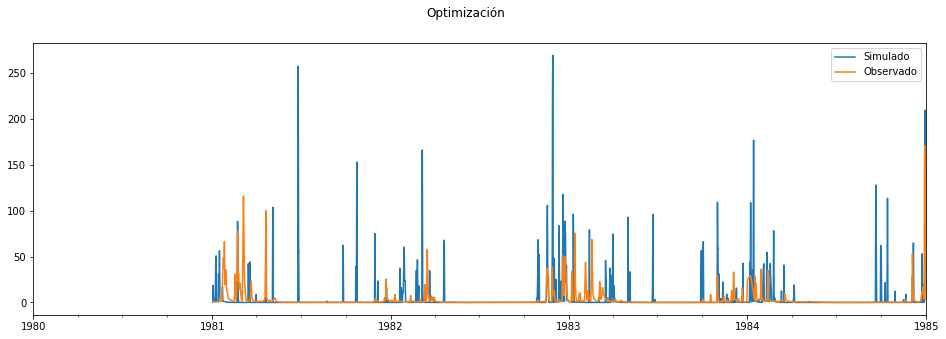

In [13]:
fig, ax = plt.subplots(figsize=(16,5))
sim.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs.plot(ax=ax,label = 'Observado')
ax.set_xlim('1980','1985')
fig.suptitle('Optimización')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs.values.flatten(), sim.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs.values.flatten(), sim.values.flatten())))

PBIAS: 0.586608902659671
NSE: -0.8707964988484471


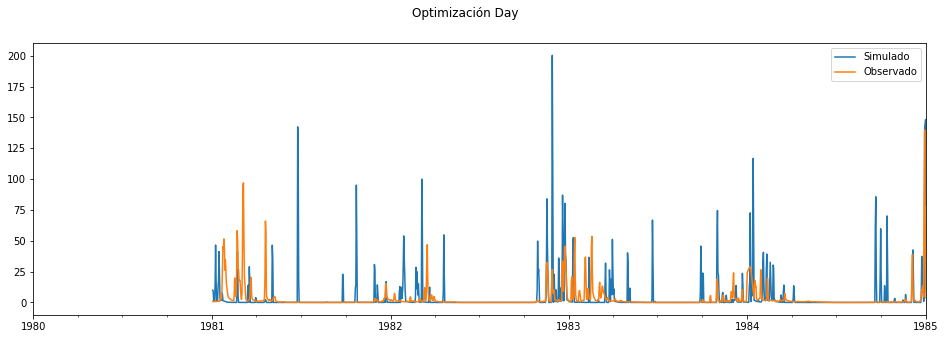

In [16]:
fig, ax = plt.subplots(figsize=(16,5))
sim_day.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs_day.plot(ax=ax,label = 'Observado')
ax.set_xlim('1980','1985')
fig.suptitle('Optimización Day')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs_day.values.flatten(), sim_day.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs_day.values.flatten(), sim_day.values.flatten())))

PBIAS: -0.11072767865596146
NSE: 0.21719339430756635


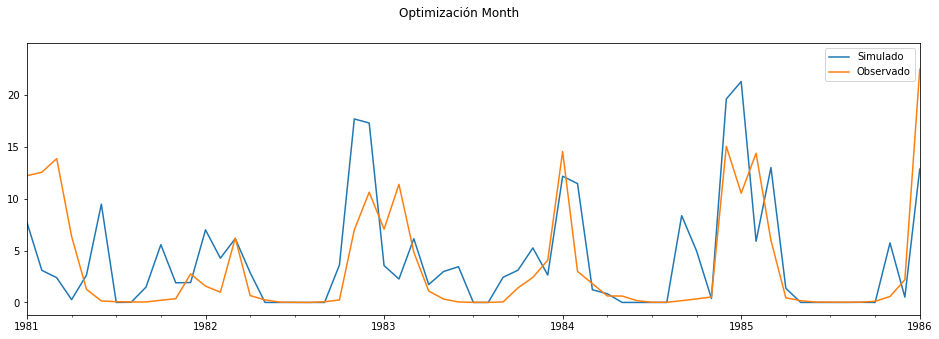

In [17]:
fig, ax = plt.subplots(figsize=(16,5))
sim_month.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs_month.plot(ax=ax,label = 'Observado')
ax.set_xlim('1981','1986')
fig.suptitle('Optimización Month')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs_month.values.flatten(), sim_month.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs_month.values.flatten(), sim_month.values.flatten())))

# Manual

In [201]:
Initial_Canopy_Storage            = 1
Canopy_Storage                    = 1
InitialSurface_Storage            = 1
Surface_Storage_Capacity          = 0.0231
Initial_Soil_Storage              = 1
Initial_Gw1_Storage               = 1
Initial_Gw2_Storage               = 1
Soil_Maximum_Infiltration         = 0.3025
Soil_Storage_Capacity             = 1
Soil_Tension_Capacity             = 1
Soil_Maximum_Percolation          = 1
Groundwater_1_Storage             = 1
Groundwater_1_Routing             = 1
Groundwater_1_Maximum_Percolation = 1
Groundwater_2_Storage             = 1
Groundwater_2_Routing             = 1
Groundwater_2_Maximum_Percolation = 1
Storage_Coefficient               = 1
GW_1_Routing_Coefficient          = 1
GW_2_Routing_Coefficient          = 1

**Parámetros que dan buen ajuste de estadísticos :**

Surface_Storage_Capacity          = 0.0231

Soil_Maximum_Infiltration         = 0.3025


In [202]:
params_values = np.array([Initial_Canopy_Storage, Canopy_Storage, 
                    InitialSurface_Storage, Surface_Storage_Capacity, 
                    Initial_Soil_Storage, Initial_Gw1_Storage, Initial_Gw2_Storage, 
                    Soil_Maximum_Infiltration, Soil_Storage_Capacity, Soil_Tension_Capacity,
                    Soil_Maximum_Percolation, Groundwater_1_Storage, Groundwater_1_Routing,
                    Groundwater_1_Maximum_Percolation, Groundwater_2_Storage, Groundwater_2_Routing,
                    Groundwater_2_Maximum_Percolation, Storage_Coefficient,
                    GW_1_Routing_Coefficient, GW_2_Routing_Coefficient])

In [203]:
hmsmodel = hms_model(Path_model, name_model, Name_run, name_basin, name_control, Time_interval_c, pathname,name_precip, startDate, endDate, Path_o, Obs, version_hms,stCal,enCal)

In [204]:
sim = hmsmodel.run_hms(*params_values)

DatetimeIndex(['1981-01-01 00:00:00', '1981-01-01 01:00:00',
               '1981-01-01 02:00:00', '1981-01-01 03:00:00',
               '1981-01-01 04:00:00', '1981-01-01 05:00:00',
               '1981-01-01 06:00:00', '1981-01-01 07:00:00',
               '1981-01-01 08:00:00', '1981-01-01 09:00:00',
               ...
               '1986-12-31 14:00:00', '1986-12-31 15:00:00',
               '1986-12-31 16:00:00', '1986-12-31 17:00:00',
               '1986-12-31 18:00:00', '1986-12-31 19:00:00',
               '1986-12-31 20:00:00', '1986-12-31 21:00:00',
               '1986-12-31 22:00:00', '1986-12-31 23:00:00'],
              dtype='datetime64[ns]', length=52584, freq=None)


In [205]:
sim_2 = pd.DataFrame(sim,index=pd.date_range(start=stCal,end = enCal+' 23:00:00',freq='h'))
sim_day = sim_2.resample('D').mean()
sim_month = sim_2.resample('M').mean()

In [206]:
Obs          = pd.read_csv('F:/TUNEZ/06_Hidrologia/Serie_caudales_OUCHTATA.csv',decimal=',',index_col=0, parse_dates=True)
Obs = Obs.iloc[:,1].resample('1h')
Obs = Obs.interpolate(method='linear')
Obs = Obs.loc[sim_2.index]

In [207]:
print('Qmed Obs: '+str(Obs.mean()))
print('Qmed Sim: '+str(sim_2.values.mean()))

print('Qmax Obs: '+str(Obs.max()))
print('Qmax Sim: '+str(sim_2.values.max()))

print('var Obs: '+str(Obs.var()))
print('var Sim: '+str(sim_2.values.var()))

Qmed Obs: 3.780341560170394
Qmed Sim: 3.802153
Qmax Obs: 250.0
Qmax Sim: 269.47928
var Obs: 145.39687344417496
var Sim: 268.93246


In [208]:
Obs_day = Obs.resample('D').mean()
Obs_month = Obs.resample('M').mean()

PBIAS: 0.5769721324607424
NSE: -1.218717643611662


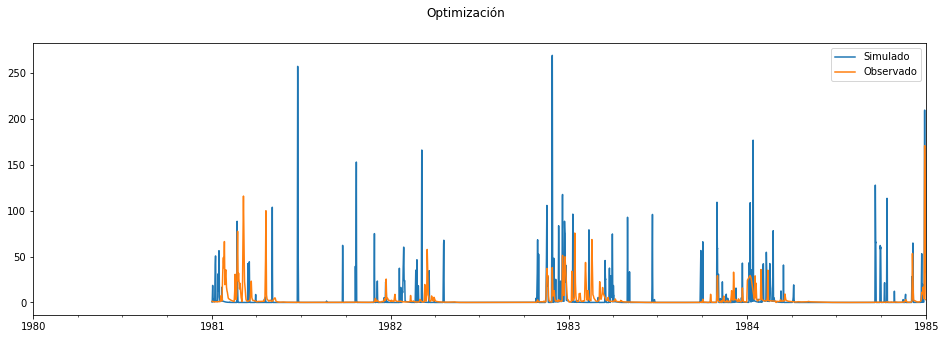

In [209]:
fig, ax = plt.subplots(figsize=(16,5))
sim_2.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs.plot(ax=ax,label = 'Observado')
ax.set_xlim('1980','1985')
fig.suptitle('Optimización')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs.values.flatten(), sim_2.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs.values.flatten(), sim_2.values.flatten())))

PBIAS: 0.5769717689310195
NSE: -0.8463361873079358


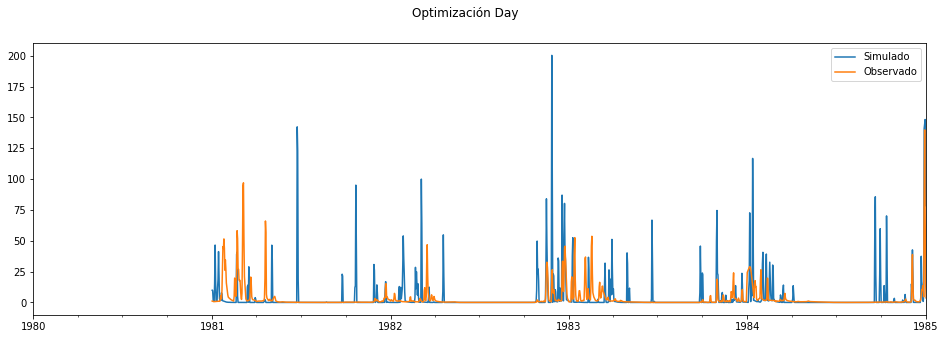

In [210]:
fig, ax = plt.subplots(figsize=(16,5))
sim_day.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs_day.plot(ax=ax,label = 'Observado')
ax.set_xlim('1980','1985')
fig.suptitle('Optimización Day')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs_day.values.flatten(), sim_day.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs_day.values.flatten(), sim_day.values.flatten())))

PBIAS: -0.34805807550562357
NSE: 0.2172019399446734


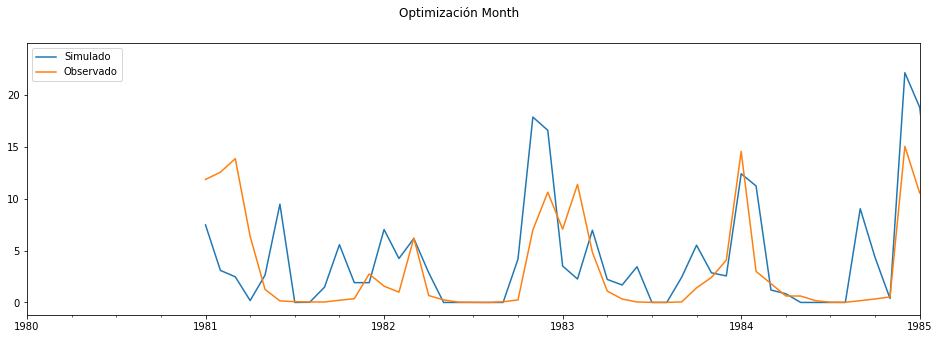

In [211]:
fig, ax = plt.subplots(figsize=(16,5))
sim_month.iloc[:,0].plot(ax=ax,label = 'Simulado')
Obs_month.plot(ax=ax,label = 'Observado')
ax.set_xlim('1980','1985')
fig.suptitle('Optimización Month')
plt.legend()
print('PBIAS: '+str(spotpy.objectivefunctions.pbias(Obs_month.values.flatten(), sim_month.values.flatten())))
print('NSE: '+str(spotpy.objectivefunctions.nashsutcliffe(Obs_month.values.flatten(), sim_month.values.flatten())))

In [212]:
def curva_caudales_clasificados(caudal_sim, caudal_obs):
    fig, ax = plt.subplots(figsize=(8,5))
    
    caudal_sort_s = sorted(caudal_sim.values,reverse=True)
    prob_s = (np.arange(1,len(caudal_sim)+1,1)-0.5)/len(caudal_sim)*100
    ax.plot(prob_s,caudal_sort_s,label = 'Simulado')
    
    caudal_sort_o = sorted(caudal_obs.values,reverse=True)
    prob_o = (np.arange(1,len(caudal_obs)+1,1)-0.5)/len(caudal_obs)*100
    ax.plot(prob_o,caudal_sort_o,label = 'Observado')
    plt.legend()
    
    ax.set_yscale('log',base=10)
    ax.set_ylim(0.001,250)
    
    

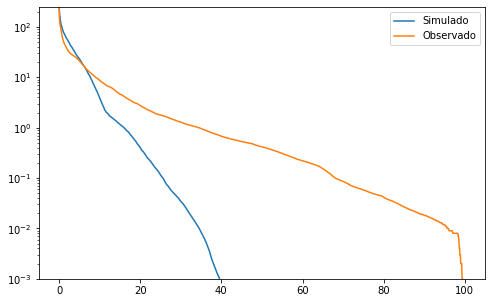

In [213]:
curva_caudales_clasificados(sim_2.iloc[:,0],Obs)

In [214]:
spotpy.objectivefunctions.correlationcoefficient(sorted(Obs.values.flatten(),reverse=True),sorted(sim_2.values.flatten(),reverse=True))

0.9872465100658826

In [230]:
Prec_caudal = Obs_day.copy()
Prec_caudal[Obs_day<=2]=0
Prec_caudal = Obs_day[Obs_day>2]*24*3600/(311*10**6)*10**3

<AxesSubplot:>

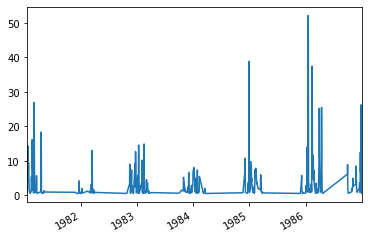

In [231]:
Prec_caudal.plot()